# **Taller Riesgo y Análisis de Fraude Bancario**

**Integrantes**
- 

- Nicoll Quesada
- Valentina Ramirez
- Joel Felipe Alba Acosta



**Librerias**
-

In [207]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
import json
import squarify
from sklearn.impute import KNNImputer
import calendar

# **1. Importación Base de Datos**

In [208]:
df = pd.read_csv("transacciones_banco.csv")

In [209]:
df.head()

,ID_Transaccion,Fecha,Cliente_ID,Monto_COP,Tipo_Transaccion,Ciudad,Estado,Dias_Cliente,Monto_Historico_Promedio
0,TRX001,2024-01-15,CLI0042,450000.0,Transferencia,Bogotá,Completada,89.0,850000
1,TRX002,2024-01-16,CLI0108,2500000.0,Retiro,Medellín,Completada,156.0,2400000
2,TRX003,2024-02-31,CLI0256,-850000.0,Transferencia,Cali,Rechazada,45.0,1200000
3,TRX004,2024-01-18,CLI0512,1200000.0,Pago,Bogotá,Completada,234.0,1150000
4,TRX005,2024-01-19,NaN,750000.0,Retiro,NaN,Pendiente,NaN,980000


In [210]:
df.tail()

,ID_Transaccion,Fecha,Cliente_ID,Monto_COP,Tipo_Transaccion,Ciudad,Estado,Dias_Cliente,Monto_Historico_Promedio
495,TRX496,2024-02-22,CLI0108,2400000.0,Retiro,Medellín,Completada,156.0,2400000
496,TRX497,2024-02-23,NaN,1950000.0,Transferencia,Bogotá,Completada,NaN,1800000
497,TRX498,2024-02-24,CLI0315,2800000.0,Pago,Bogotá,Completada,12.0,2100000
498,TRX499,2024-02-25,CLI0789,920000.0,Transferencia,Medellín,Completada,567.0,920000
499,TRX500,2024-02-26,NaN,1450000.0,Transferencia,Cali,Completada,NaN,1350000


# **2. Análisis General Base de Datos**

## **2.1 Información General**

In [211]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_Transaccion            500 non-null    str    
 1   Fecha                     499 non-null    str    
 2   Cliente_ID                357 non-null    str    
 3   Monto_COP                 479 non-null    float64
 4   Tipo_Transaccion          500 non-null    str    
 5   Ciudad                    498 non-null    str    
 6   Estado                    500 non-null    str    
 7   Dias_Cliente              357 non-null    float64
 8   Monto_Historico_Promedio  500 non-null    int64  
dtypes: float64(2), int64(1), str(6)
memory usage: 35.3 KB


## **2.2 Datos Únicos por Columna**

In [212]:
for c in df.columns:
    print(f"La columna {c} tiene {df[c].nunique()} valores únicos")

La columna ID_Transaccion tiene 500 valores únicos
La columna Fecha tiene 86 valores únicos
La columna Cliente_ID tiene 8 valores únicos
La columna Monto_COP tiene 60 valores únicos
La columna Tipo_Transaccion tiene 3 valores únicos
La columna Ciudad tiene 5 valores únicos
La columna Estado tiene 3 valores únicos
La columna Dias_Cliente tiene 7 valores únicos
La columna Monto_Historico_Promedio tiene 34 valores únicos


## **2.3 Datos Faltantes por Columna**

In [213]:
for c in df.columns:
    print(f"La columna {c} tiene {df[c].isnull().sum()} valores faltantes")

La columna ID_Transaccion tiene 0 valores faltantes
La columna Fecha tiene 1 valores faltantes
La columna Cliente_ID tiene 143 valores faltantes
La columna Monto_COP tiene 21 valores faltantes
La columna Tipo_Transaccion tiene 0 valores faltantes
La columna Ciudad tiene 2 valores faltantes
La columna Estado tiene 0 valores faltantes
La columna Dias_Cliente tiene 143 valores faltantes
La columna Monto_Historico_Promedio tiene 0 valores faltantes


# **3. Análisis Univariado**

In [214]:
def resumen_estadistico_df(df, columna):
    """
    Calcula estadísticas descriptivas avanzadas para una columna numérica
    de un DataFrame y devuelve un DataFrame con los resultados.

    Parámetros:
        df (pd.DataFrame): DataFrame de entrada
        columna (str): Nombre de la columna numérica

    Retorna:
        pd.DataFrame: DataFrame con las métricas estadísticas
    """
    
    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no existe en el DataFrame.")
    
    if not np.issubdtype(df[columna].dtype, np.number):
        raise TypeError(f"La columna '{columna}' no es numérica.")
    
    serie = df[columna].dropna()
    
    media = serie.mean()
    std = serie.std()
    
    resultados = {
        "media": media,
        "mediana": serie.median(),
        "q1": serie.quantile(0.25),
        "q3": serie.quantile(0.75),
        "min": serie.min(),
        "max": serie.max(),
        "rango": serie.max() - serie.min(),
        "coef_variacion": std / media if media != 0 else np.nan,
        "varianza": serie.var(),
        "std": std,
        "asimetria": serie.skew(),
        "curtosis": serie.kurt()
    }
    
    # Convertir el diccionario a DataFrame (una fila)
    df_resultado = pd.DataFrame(resultados, index=[columna])
    
    return df_resultado

def plot_numeric_data(column):

    palette = sns.color_palette("Set2", 3)
    colors = np.random.choice(range(len(palette)), 3, replace=False)

    fig, ax = plt.subplots(1, 3, figsize=(14,4))

    fig.suptitle(f"Análisis Gráfico {column}", fontsize=12, fontweight="bold")

    sns.histplot(df[column], kde=False, ax=ax[0], color=palette[colors[0]])
    ax[0].set_title(f"Histograma de {column}")
    ax[0].set_xlabel(column)
    ax[0].set_ylabel("Frecuencia")

    sns.boxplot(x=df[column], ax=ax[1], color=palette[colors[1]])
    ax[1].set_title(f"Boxplot de {column}")
    ax[1].set_xlabel(column)
    ax[1].set_ylabel("")

    sns.kdeplot(x=df[column], ax=ax[2], color=palette[colors[2]], linewidth=2)
    ax[2].set_title(f"Densidad (KDE) de {column}")
    ax[2].set_xlabel(column)
    ax[2].set_ylabel("Densidad")

    plt.tight_layout()
    plt.show()

def resumen_estadistico_categorico(df, columna):

    import pandas as pd
    
    # Frecuencia absoluta
    freq = df[columna].value_counts(dropna=False)
    
    # Frecuencia relativa (%)
    porcentaje = df[columna].value_counts(normalize=True, dropna=False) * 100
    
    # Crear DataFrame
    resumen = pd.DataFrame({
        'Frecuencia': freq,
        'Porcentaje (%)': porcentaje.round(2)
    })
    
    # Moda
    moda = df[columna].mode()
    
    # Agregar moda como columna (repetida para visualización)
    resumen['Moda'] = moda.iloc[0] if not moda.empty else None
    
    return resumen

def plot_categoric_data(df, columna):
    import matplotlib.pyplot as plt
    
    # Conteo ordenado
    conteo = df[columna].value_counts().sort_values(ascending=False)
    
    plt.figure(figsize=(10,6))
    colors = plt.cm.Set1(range(len(conteo)))
    bars = plt.bar(
        conteo.index.astype(str), 
        conteo.values,
        edgecolor='black',
        color=colors
    )
    
    # Título y etiquetas
    plt.title(f"Análisis Gráfico Columna {columna}", fontweight='bold')
    plt.xlabel("Categoria")
    plt.ylabel("Cantidad")
    
    # Valores encima de las barras
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## **3.1 Monto COP**

### **3.1.1 Valores Únicos**

In [215]:
df['Monto_COP'].unique()

array([ 4.50e+05,  2.50e+06, -8.50e+05,  1.20e+06,  7.50e+05,  1.25e+08,
        8.90e+05,  0.00e+00,  3.40e+06,  6.50e+05,  2.10e+06,  1.80e+06,
        9.50e+05,  2.30e+06,  1.90e+06,  4.50e+07,  1.50e+06,  2.20e+06,
        2.80e+06,       nan,  1.25e+06,  1.10e+06,  2.05e+06,  8.50e+05,
        1.45e+06,  7.80e+05,  1.95e+06,  1.70e+06,  3.20e+06,  1.05e+06,
        2.65e+06,  5.50e+05,  2.40e+06,  1.85e+06,  2.90e+06,  3.10e+06,
        7.20e+05,  2.60e+06,  9.80e+05,  6.20e+05,  1.40e+06,  2.95e+06,
        3.50e+06,  1.60e+06,  7.40e+05,  2.70e+06,  9.20e+05,  1.75e+06,
        2.35e+06,  8.20e+05,  1.00e+06,  6.00e+05,  3.30e+06,  1.35e+06,
        7.00e+05,  8.80e+05,  2.00e+06,  3.00e+06,  9.00e+05,  1.15e+06,
        1.65e+06])

### **3.1.2 Análisis Descriptivo**

In [216]:
import pandas as pd

columns = ['Monto_COP','Dias_Cliente','Monto_Historico_Promedio']

dfs = []

for c in columns:
    temp_df = resumen_estadistico_df(df, c)
    temp_df['Variable'] = c  # para identificar de qué columna viene
    dfs.append(temp_df)

resultado_final = pd.concat(dfs, axis=0, ignore_index=True)
resultado_final

,media,mediana,q1,q3,min,max,rango,coef_variacion,varianza,std,asimetria,curtosis,Variable
0,2.105971e+06,1800000.0,1100000.0,2300000.0,-850000.0,125000000.0,125850000.0,2.851852,3.607105e+13,6.005918e+06,18.761490,373.882789,Monto_COP
1,1.821261e+02,156.0,45.0,234.0,12.0,567.0,555.0,0.948757,2.985757e+04,1.727934e+02,1.362516,0.768819,Dias_Cliente
2,1.423140e+06,1200000.0,920000.0,2100000.0,550000.0,3200000.0,2650000.0,0.438860,3.900749e+11,6.245598e+05,0.392335,-1.240937,Monto_Historico_Promedio


### **3.1.3 Visualización Gráfica**

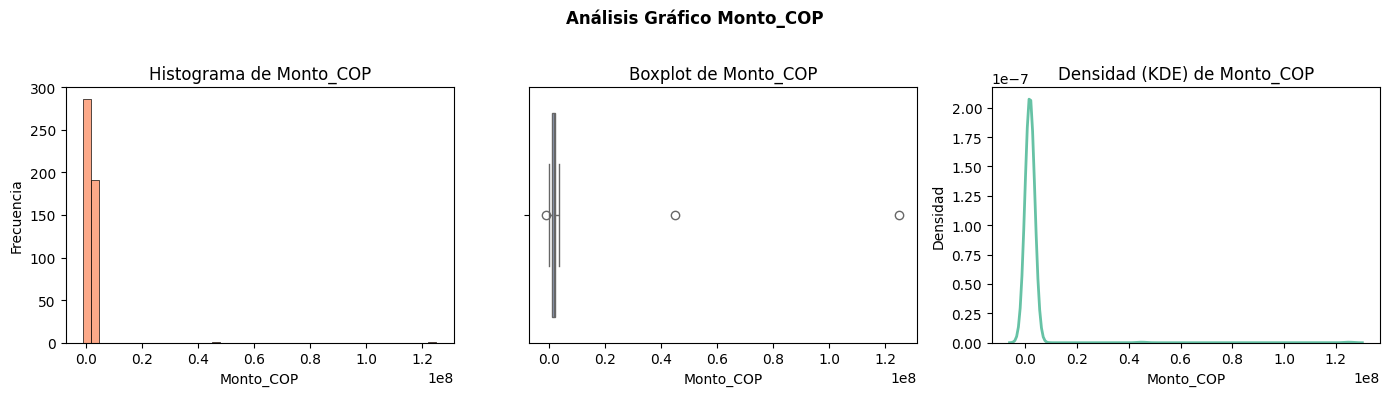

In [217]:
plot_numeric_data('Monto_COP')

## **3.2 Dias Cliente**

### **3.2.1 Valores Únicos**

In [218]:
df['Dias_Cliente'].unique()

array([ 89., 156.,  45., 234.,  nan,  12., 567., 178.])

### **3.2.2 Análisis Descriptivo**

In [219]:
resumen_estadistico_df(df,'Dias_Cliente')

,media,mediana,q1,q3,min,max,rango,coef_variacion,varianza,std,asimetria,curtosis
Dias_Cliente,182.12605,156.0,45.0,234.0,12.0,567.0,555.0,0.948757,29857.571145,172.793435,1.362516,0.768819


### **3.3.3 Visualización Gráfica**

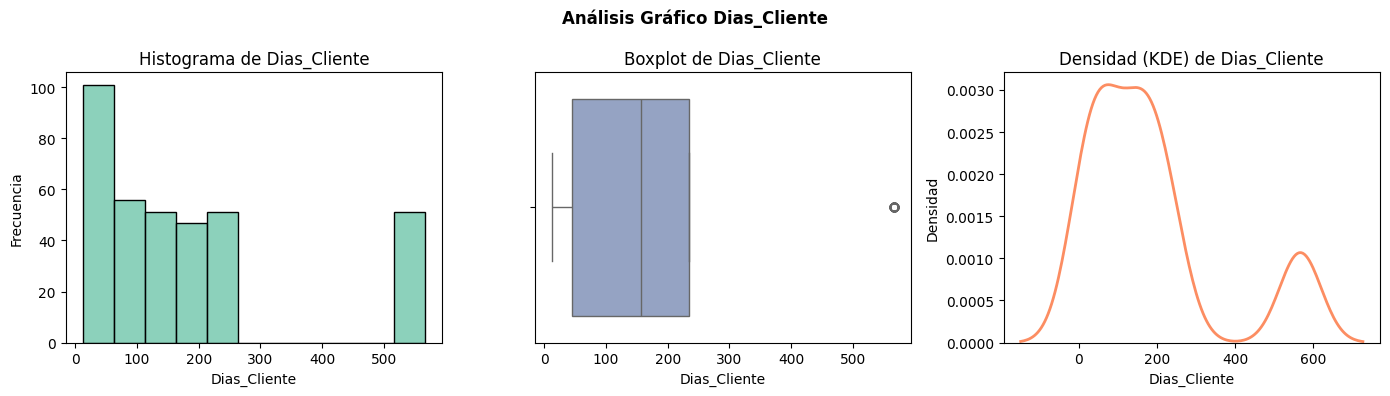

In [220]:
plot_numeric_data('Dias_Cliente')

## **3.3 Monto Historico Acumulado**

### **3.3.1 Valores Únicos**

In [221]:
df['Monto_Historico_Promedio'].unique()

array([ 850000, 2400000, 1200000, 1150000,  980000, 2100000,  920000,
       3200000,  580000, 1400000, 1050000, 2150000,  950000, 2950000,
       2450000, 1850000, 1350000, 2500000, 1100000,  550000, 2650000,
        800000, 1950000, 2350000, 2250000, 1750000, 1900000, 2050000,
       2550000, 1650000,  900000, 1800000, 1300000, 1000000])

### **3.3.2 Análisis Descriptivo**

In [222]:
resumen_estadistico_df(df,"Monto_Historico_Promedio")

,media,mediana,q1,q3,min,max,rango,coef_variacion,varianza,std,asimetria,curtosis
Monto_Historico_Promedio,1423140.0,1200000.0,920000.0,2100000.0,550000,3200000,2650000,0.43886,3.900749e+11,624559.757093,0.392335,-1.240937


### **3.3.3 Análisis Gráfico**

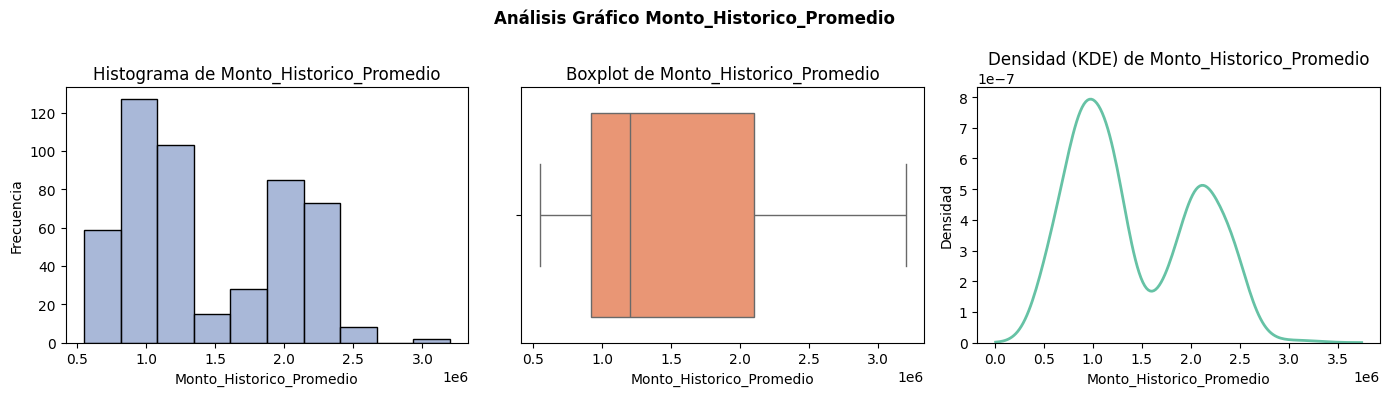

In [223]:
plot_numeric_data('Monto_Historico_Promedio')

## **3.4 Cliente ID**

### **3.4.1 Valores Únicos**

In [224]:
df['Cliente_ID'].unique()

<StringArray>
['CLI0042', 'CLI0108', 'CLI0256', 'CLI0512',       nan, 'CLI0315', 'CLI0789',
 'CLI0198', 'CLI0654']
Length: 9, dtype: str

### **3.4.2 Análisis Descriptivo**

In [225]:
resumen_estadistico_categorico(df,'Cliente_ID')

,Frecuencia,Porcentaje (%),Moda
Cliente_ID,,,
NaN,143,28.6,CLI0042
CLI0042,56,11.2,CLI0042
CLI0108,51,10.2,CLI0042
CLI0315,51,10.2,CLI0042
CLI0789,51,10.2,CLI0042
CLI0256,50,10.0,CLI0042
CLI0512,50,10.0,CLI0042
CLI0654,47,9.4,CLI0042
CLI0198,1,0.2,CLI0042


### **3.4.3 Visualización Gráfica**

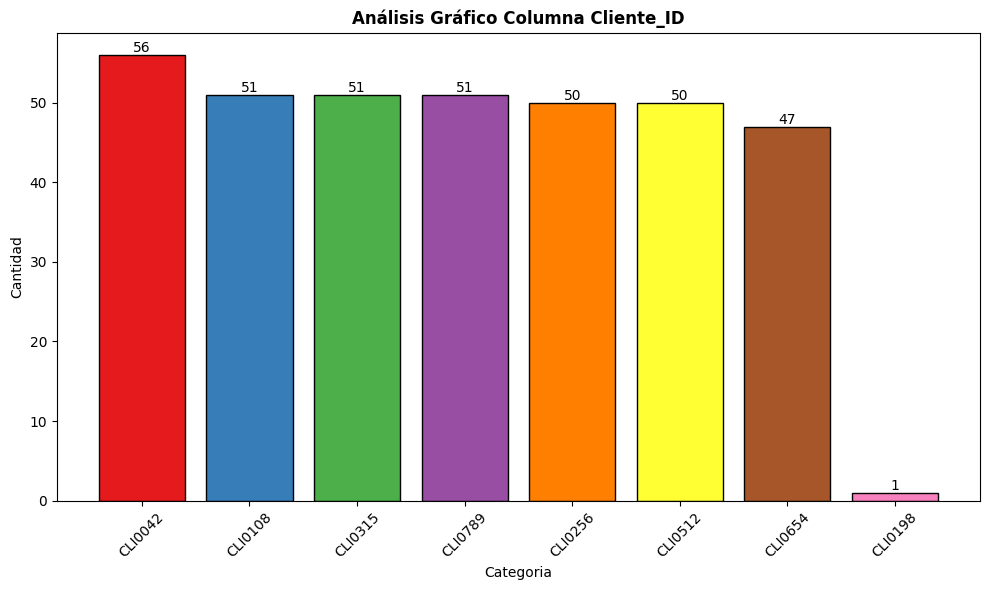

In [226]:
plot_categoric_data(df,'Cliente_ID')

## **3.5 Ciudad**

### **3.5.1 Valores Únicos**

In [227]:
df['Ciudad'].unique()

<StringArray>
['Bogotá', 'Medellín', 'Cali', nan, 'Cartagena', 'Barranquilla']
Length: 6, dtype: str

### **3.5.2 Análisis Descriptivo**

In [228]:
resumen_estadistico_categorico(df,'Ciudad')

,Frecuencia,Porcentaje (%),Moda
Ciudad,,,
Bogotá,234,46.8,Bogotá
Medellín,144,28.8,Bogotá
Cali,68,13.6,Bogotá
Cartagena,51,10.2,Bogotá
NaN,2,0.4,Bogotá
Barranquilla,1,0.2,Bogotá


### **3.5.3 Visualización Gráfica**

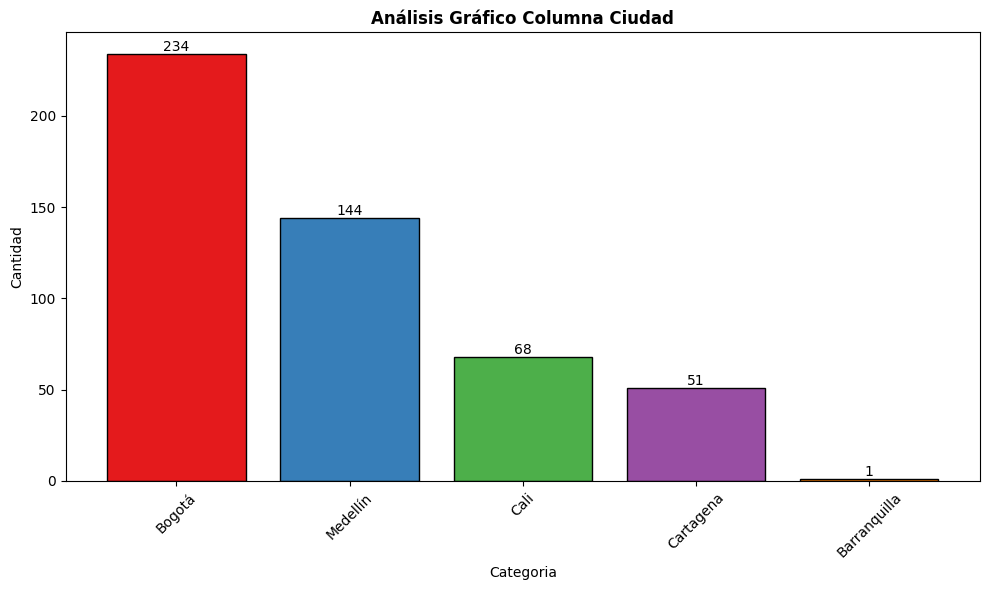

In [229]:
plot_categoric_data(df,'Ciudad')

## **3.5 Estado**

### **3.5.1 Valores Únicos**

In [230]:
df['Estado'].unique()

<StringArray>
['Completada', 'Rechazada', 'Pendiente']
Length: 3, dtype: str

### **3.5.2 Análisis Descriptivo**

In [231]:
resumen_estadistico_categorico(df,'Estado')

,Frecuencia,Porcentaje (%),Moda
Estado,,,
Completada,474,94.8,Completada
Rechazada,22,4.4,Completada
Pendiente,4,0.8,Completada


### **3.5.3 Visualización Gráfica**

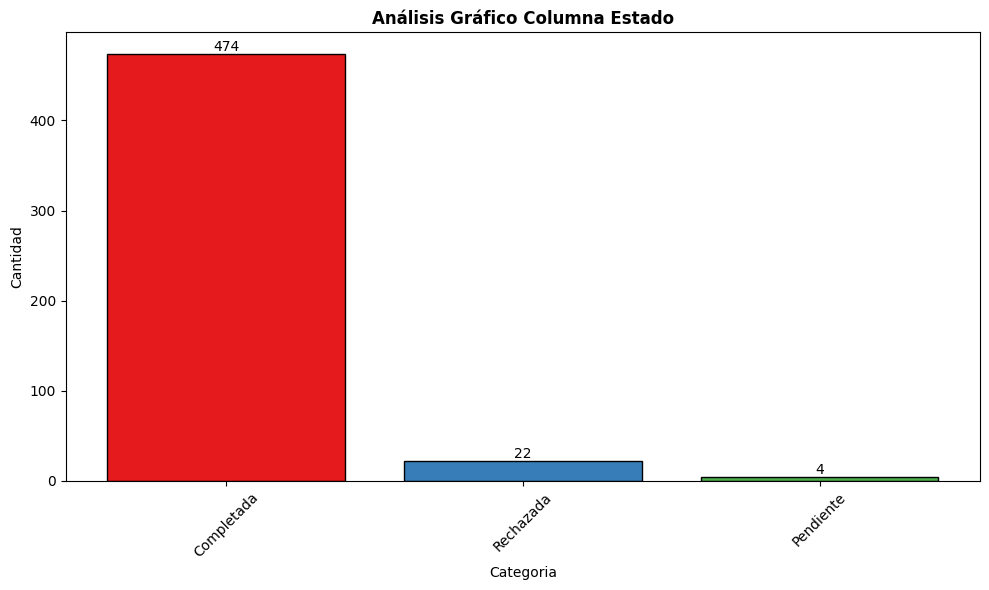

In [232]:
plot_categoric_data(df,'Estado')

## **3.6 Tipo Transaccion**

### **3.6.1 Valores Únicos**

In [233]:
df['Tipo_Transaccion'].unique()

<StringArray>
['Transferencia', 'Retiro', 'Pago']
Length: 3, dtype: str

### **3.6.2 Análisis Descriptivo**

In [234]:
resumen_estadistico_categorico(df,'Tipo_Transaccion')

,Frecuencia,Porcentaje (%),Moda
Tipo_Transaccion,,,
Transferencia,263,52.6,Transferencia
Pago,129,25.8,Transferencia
Retiro,108,21.6,Transferencia


### **3.6.3 Visualización Gráfica**

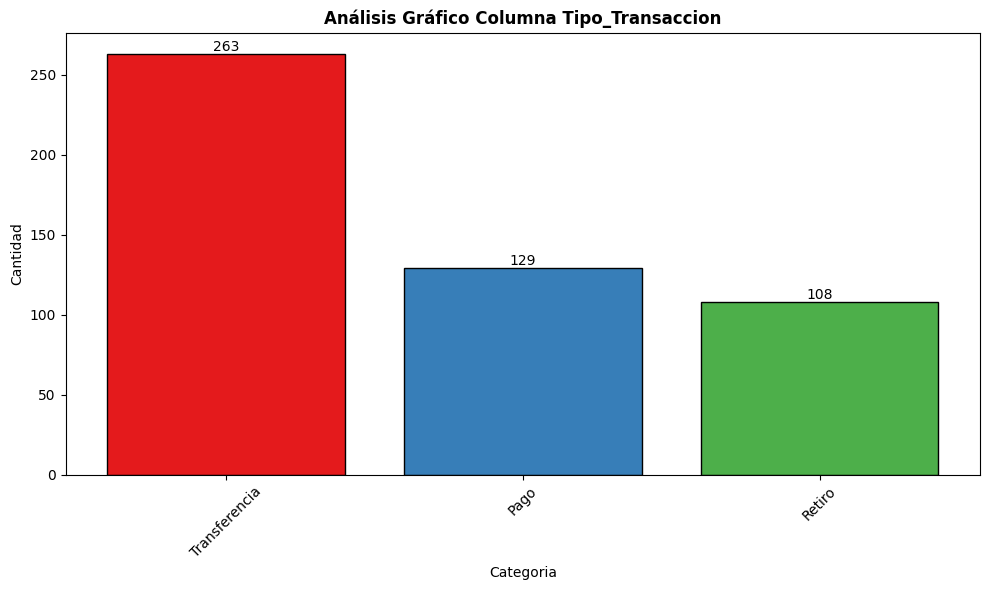

In [235]:
plot_categoric_data(df,'Tipo_Transaccion')

In [236]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_Transaccion            500 non-null    str    
 1   Fecha                     499 non-null    str    
 2   Cliente_ID                357 non-null    str    
 3   Monto_COP                 479 non-null    float64
 4   Tipo_Transaccion          500 non-null    str    
 5   Ciudad                    498 non-null    str    
 6   Estado                    500 non-null    str    
 7   Dias_Cliente              357 non-null    float64
 8   Monto_Historico_Promedio  500 non-null    int64  
dtypes: float64(2), int64(1), str(6)
memory usage: 35.3 KB


## **3.7 Fecha**

### **3.7.1 Valores Únicos**

In [237]:
df['Fecha'].unique()

<StringArray>
['2024-01-15', '2024-01-16', '2024-02-31', '2024-01-18', '2024-01-19',
 '2024-01-20', '2024-01-21', '2024-01-22',          nan, '2023-11-05',
 '2024-01-25', '2024-01-26', '2024-01-27', '2024-01-28', '2024-01-29',
 '2024-01-30', '2024-01-31', '2024-02-01', '2024-02-02', '2024-02-03',
 '2024-02-04', '2024-02-05', '2024-02-06', '2024-02-07', '2024-02-08',
 '2024-02-09', '2024-02-10', '2024-02-11', '2024-02-12', '2024-02-13',
 '2024-02-14', '2024-02-15', '2024-02-16', '2024-02-17', '2024-02-18',
 '2024-02-19', '2024-02-20', '2024-02-21', '2024-02-22', '2024-02-23',
 '2024-02-24', '2024-02-25', '2024-02-26', '2024-02-27', '2024-02-28',
 '2024-02-29', '2024-03-01', '2024-03-02', '2024-03-03', '2024-03-04',
 '2024-03-05', '2024-03-06', '2024-03-07', '2024-03-08', '2024-03-09',
 '2024-03-10', '2024-03-11', '2024-03-12', '2024-03-13', '2024-03-14',
 '2024-03-15', '2024-03-16', '2024-03-17', '2024-03-18', '2024-03-19',
 '2024-03-20', '2024-03-21', '2024-03-22', '2024-03-23', '2024-

### **3.7.2 Análisis Descriptivo**

In [238]:
resumen_estadistico_categorico(df,'Fecha')

,Frecuencia,Porcentaje (%),Moda
Fecha,,,
2024-01-25,8,1.6,2024-01-25
2024-01-26,7,1.4,2024-01-25
2024-01-27,7,1.4,2024-01-25
2024-01-28,7,1.4,2024-01-25
2024-02-01,7,1.4,2024-01-25
...,...,...,...
2024-01-10,1,0.2,2024-01-25
2024-01-11,1,0.2,2024-01-25
2024-01-12,1,0.2,2024-01-25


# **4. Análisis Multivariado**

(array([0.5, 1.5, 2.5]),
 [Text(0.5, 0, 'Monto_COP'),
  Text(1.5, 0, 'Dias_Cliente'),
  Text(2.5, 0, 'Monto_Historico_Promedio')])

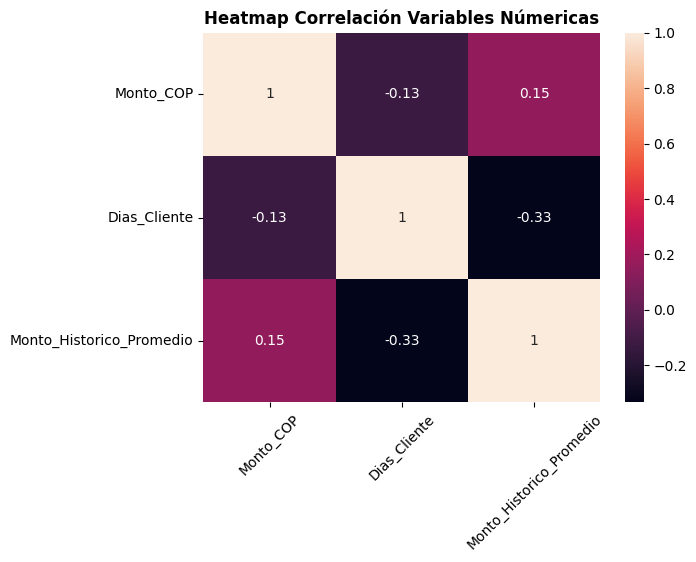

In [239]:
sns.heatmap(df[['Monto_COP','Dias_Cliente','Monto_Historico_Promedio']].corr(),annot=True)
plt.title("Heatmap Correlación Variables Númericas",fontweight='bold')
plt.xticks(rotation=45)

In [240]:
tabla = pd.crosstab(df['Tipo_Transaccion'], df['Estado'])
tabla

Estado,Completada,Pendiente,Rechazada
Tipo_Transaccion,,,
Pago,125,0,4
Retiro,105,2,1
Transferencia,244,2,17


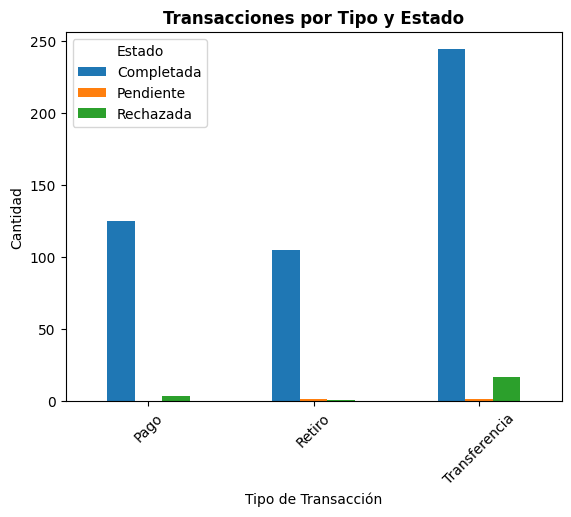

In [241]:
import matplotlib.pyplot as plt

# Graficar directamente desde el crosstab
tabla.plot(kind='bar', stacked=False)

plt.title('Transacciones por Tipo y Estado',fontweight='bold')
plt.xlabel('Tipo de Transacción')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.legend(title='Estado')
plt.show()

In [242]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_Transaccion            500 non-null    str    
 1   Fecha                     499 non-null    str    
 2   Cliente_ID                357 non-null    str    
 3   Monto_COP                 479 non-null    float64
 4   Tipo_Transaccion          500 non-null    str    
 5   Ciudad                    498 non-null    str    
 6   Estado                    500 non-null    str    
 7   Dias_Cliente              357 non-null    float64
 8   Monto_Historico_Promedio  500 non-null    int64  
dtypes: float64(2), int64(1), str(6)
memory usage: 35.3 KB


# **5. Detección de Outliers**

## **5.1 Fecha**

In [243]:
def separar_fecha(df, nombre_columna):
    # 1. Convertir a datetime (coerciendo errores a NaT/NaN)
    fechas_dt = pd.to_datetime(df[nombre_columna], errors='coerce')
    
    # 2. Crear las 3 columnas nuevas
    df['Año'] = fechas_dt.dt.year.astype('Int64')
    df['Mes'] = fechas_dt.dt.month.astype('Int64')
    df['Dia'] = fechas_dt.dt.day.astype('Int64')
    
    # 3. Borrar la columna original
    df = df.drop(columns=[nombre_columna])
    
    return df


df_out_fecha = df.copy()
df_out_fecha = separar_fecha(df_out_fecha ,'Fecha')

In [244]:
df_out_fecha[df_out_fecha['Dia'].isna() ]

,ID_Transaccion,Cliente_ID,Monto_COP,Tipo_Transaccion,Ciudad,Estado,Dias_Cliente,Monto_Historico_Promedio,Año,Mes,Dia
2,TRX003,CLI0256,-850000.0,Transferencia,Cali,Rechazada,45.0,1200000,<NA>,<NA>,<NA>
8,TRX009,CLI0198,3400000.0,Retiro,Bogotá,Completada,234.0,3200000,<NA>,<NA>,<NA>


**Observaciones**
- La fecha de transacción de estos clientes, no es válida. Estas transacciones se deben revisar con precaución.

## **5.2 Monto Historico Promedio**

In [245]:
def detect_outliers(df,column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    print("Cuartil 1: ",Q1)
    print("Cuartil 3: ",Q3)
    
    IQR = Q3-Q1 

    outliers_bottom = df[df[column] < (Q1-1.5*IQR)]
    outliers_top = df[df[column] > (Q3+1.5*IQR)]

    return outliers_bottom,outliers_top 

out_hist_bot, out_hist_top = detect_outliers(df,'Monto_Historico_Promedio')


Cuartil 1:  920000.0
Cuartil 3:  2100000.0


### **5.2.1 Outliers Inferiores**

In [246]:
out_hist_bot

,ID_Transaccion,Fecha,Cliente_ID,Monto_COP,Tipo_Transaccion,Ciudad,Estado,Dias_Cliente,Monto_Historico_Promedio


### **5.2.2 Outliers Superiores**

In [247]:
out_hist_top

,ID_Transaccion,Fecha,Cliente_ID,Monto_COP,Tipo_Transaccion,Ciudad,Estado,Dias_Cliente,Monto_Historico_Promedio


In [248]:
df.head()

,ID_Transaccion,Fecha,Cliente_ID,Monto_COP,Tipo_Transaccion,Ciudad,Estado,Dias_Cliente,Monto_Historico_Promedio
0,TRX001,2024-01-15,CLI0042,450000.0,Transferencia,Bogotá,Completada,89.0,850000
1,TRX002,2024-01-16,CLI0108,2500000.0,Retiro,Medellín,Completada,156.0,2400000
2,TRX003,2024-02-31,CLI0256,-850000.0,Transferencia,Cali,Rechazada,45.0,1200000
3,TRX004,2024-01-18,CLI0512,1200000.0,Pago,Bogotá,Completada,234.0,1150000
4,TRX005,2024-01-19,NaN,750000.0,Retiro,NaN,Pendiente,NaN,980000


## **5.3 Monto_COP**

In [249]:
out_monto_bot,out_monto_top = detect_outliers(df,'Monto_COP')

Cuartil 1:  1100000.0
Cuartil 3:  2300000.0


### **5.3.1 Outliers Inferiores**

In [250]:
out_monto_bot

,ID_Transaccion,Fecha,Cliente_ID,Monto_COP,Tipo_Transaccion,Ciudad,Estado,Dias_Cliente,Monto_Historico_Promedio
2,TRX003,2024-02-31,CLI0256,-850000.0,Transferencia,Cali,Rechazada,45.0,1200000


In [251]:
out_monto_top

,ID_Transaccion,Fecha,Cliente_ID,Monto_COP,Tipo_Transaccion,Ciudad,Estado,Dias_Cliente,Monto_Historico_Promedio
5,TRX006,2024-01-20,CLI0315,125000000.0,Transferencia,Bogotá,Completada,12.0,2100000
16,TRX017,2024-01-27,CLI0315,45000000.0,Transferencia,Bogotá,Completada,12.0,2100000


# **6. Análisis Valores Faltantes**

# **7. Análisis Por Cliente**

In [252]:
df['Cliente_ID'].unique()

<StringArray>
['CLI0042', 'CLI0108', 'CLI0256', 'CLI0512',       nan, 'CLI0315', 'CLI0789',
 'CLI0198', 'CLI0654']
Length: 9, dtype: str

In [253]:
df['Cliente_ID'].value_counts()

Cliente_ID
CLI0042    56
CLI0108    51
CLI0315    51
CLI0789    51
CLI0256    50
CLI0512    50
CLI0654    47
CLI0198     1
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Cliente_ID'>

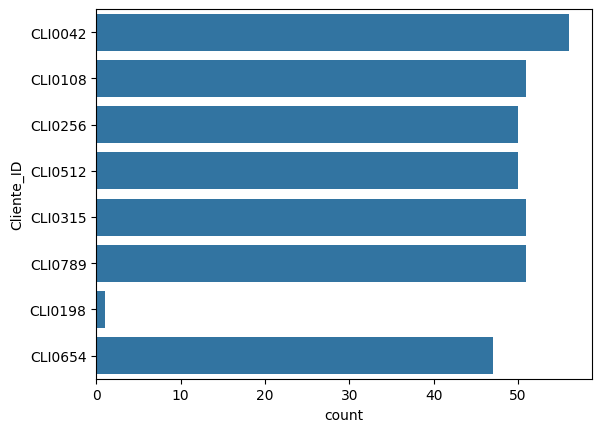

In [254]:
sns.countplot(df['Cliente_ID'])

**Observaciones**
- El cliente CLI198 solo aparece una vez, en una operación completada en una fecha no válida.

<Axes: xlabel='Cliente_ID', ylabel='Dias_Cliente'>

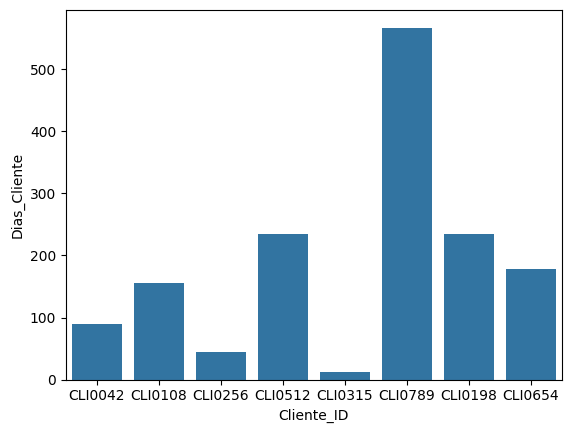

In [255]:
sns.barplot(df,x='Cliente_ID',y='Dias_Cliente')

In [266]:
def graficos_cliente(df, cliente_id):

    # 1. DF temporal filtrado
    df_temp = df[df['Cliente_ID'] == cliente_id].copy()

    # 2. Convertir tipos
    df_temp['Fecha'] = pd.to_datetime(df_temp['Fecha'], errors='coerce')
    df_temp['Monto_COP'] = pd.to_numeric(df_temp['Monto_COP'], errors='coerce')
    df_temp['Monto_Historico_Promedio'] = pd.to_numeric(df_temp['Monto_Historico_Promedio'], errors='coerce')

    # 3. Limpiar nulos
    df_temp = df_temp.dropna(subset=['Fecha', 'Monto_COP'])

    # 4. Ordenar
    df_temp = df_temp.sort_values('Fecha')

    # 5. Crear días relativos
    df_temp['Dia_num'] = (df_temp['Fecha'] - df_temp['Fecha'].min()).dt.days

    # 🔥 Obtener promedio histórico (único por cliente)
    promedio = df_temp['Monto_Historico_Promedio'].dropna().iloc[0]

    # 🎨 6. Figura
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # --- Scatterplot ---
    axes[0, 0].scatter(df_temp['Dia_num'], df_temp['Monto_COP'], alpha=0.7)

    # 🔴 Línea horizontal del promedio
    axes[0, 0].axhline(promedio, linestyle='--')

    # Etiqueta de la línea
    axes[0, 0].text(df_temp['Dia_num'].max(), promedio,
                    f'MHP: {int(promedio)}',
                    va='bottom')

    axes[0, 0].set_title('Monto vs Tiempo', fontweight='bold')
    axes[0, 0].set_xlabel('Días')
    axes[0, 0].set_ylabel('Monto_COP')
    axes[0, 0].grid()

    # 🔧 Función para añadir etiquetas
    def add_labels(ax):
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(f'{int(height)}',
                            (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom',
                            fontsize=9)

    # 🔧 Función para ordenar categorías
    def get_order(col):
        return df_temp[col].value_counts().index

    # --- Tipo Transacción ---
    sns.countplot(data=df_temp,
                  x='Tipo_Transaccion',
                  hue='Tipo_Transaccion',
                  order=get_order('Tipo_Transaccion'),
                  palette='Set1',
                  edgecolor='black',
                  ax=axes[0, 1],
                  legend=False)
    axes[0, 1].set_title('Tipo Transacción', fontweight='bold')
    axes[0, 1].tick_params(axis='x', rotation=45)
    add_labels(axes[0, 1])

    # --- Estado ---
    sns.countplot(data=df_temp,
                  x='Estado',
                  hue='Estado',
                  order=get_order('Estado'),
                  palette='Set1',
                  edgecolor='black',
                  ax=axes[1, 0],
                  legend=False)
    axes[1, 0].set_title('Estado', fontweight='bold')
    add_labels(axes[1, 0])

    # --- Ciudad ---
    sns.countplot(data=df_temp,
                  x='Ciudad',
                  hue='Ciudad',
                  order=get_order('Ciudad'),
                  palette='Set1',
                  edgecolor='black',
                  ax=axes[1, 1],
                  legend=False)
    axes[1, 1].set_title('Ciudad', fontweight='bold')
    axes[1, 1].tick_params(axis='x', rotation=45)
    add_labels(axes[1, 1])

    # 🏷️ Título general
    fig.suptitle(f'Análisis Cliente ID {cliente_id}',
                 fontsize=20, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## **7.1 CLI 0042**

In [257]:
df_grouped = df.groupby('Fecha')['Monto_COP'].sum().reset_index()

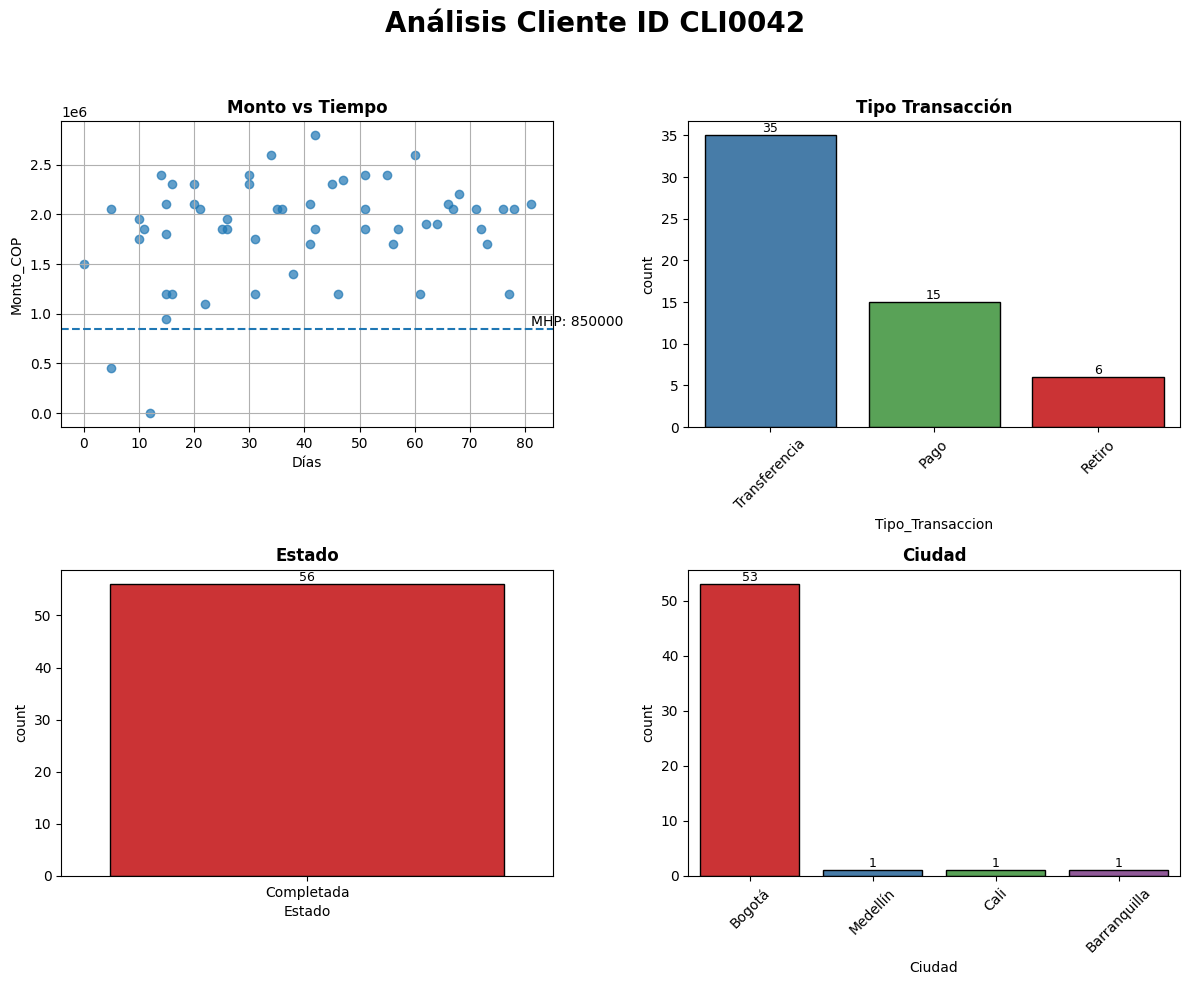

In [267]:
graficos_cliente(df,'CLI0042')

In [259]:
df[df['Cliente_ID']=="CLI0042"].sort_values('Fecha').head(3)

,ID_Transaccion,Fecha,Cliente_ID,Monto_COP,Tipo_Transaccion,Ciudad,Estado,Dias_Cliente,Monto_Historico_Promedio
144,TRX145,2024-01-10,CLI0042,1500000.0,Retiro,Bogotá,Completada,89.0,850000
0,TRX001,2024-01-15,CLI0042,450000.0,Transferencia,Bogotá,Completada,89.0,850000
380,TRX381,2024-01-15,CLI0042,2050000.0,Pago,Bogotá,Completada,89.0,850000


## **7.2 CLI0108**

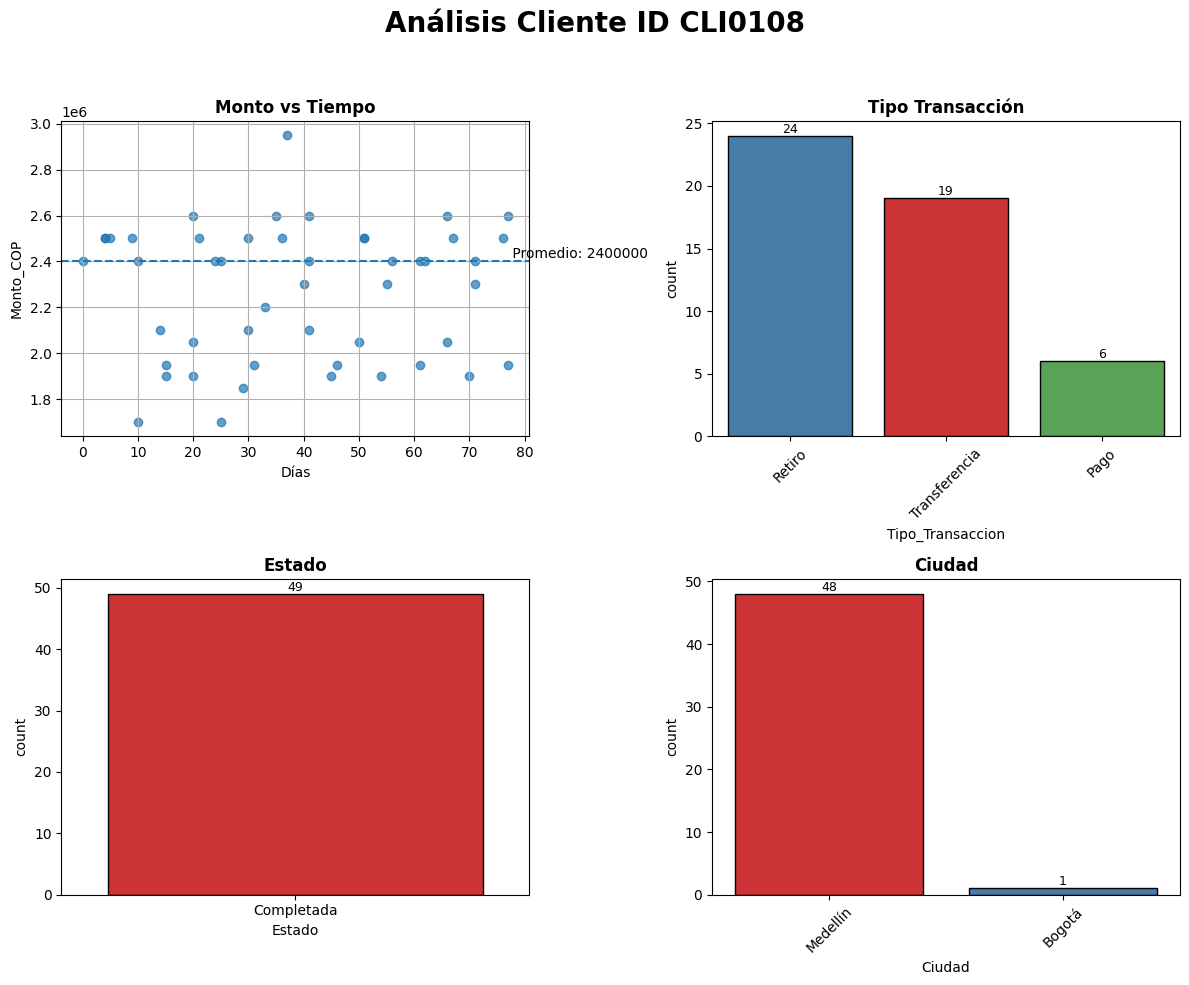

In [260]:
graficos_cliente(df,'CLI0108')

In [ ]:
df[df['Cliente_ID']=="CLI0108"].sort_values('Fecha')

## **7.3 CLI0256**

/tmp/ipykernel_20656/3406024015.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_temp['Fecha'] = pd.to_datetime(df_temp['Fecha'], errors='coerce')


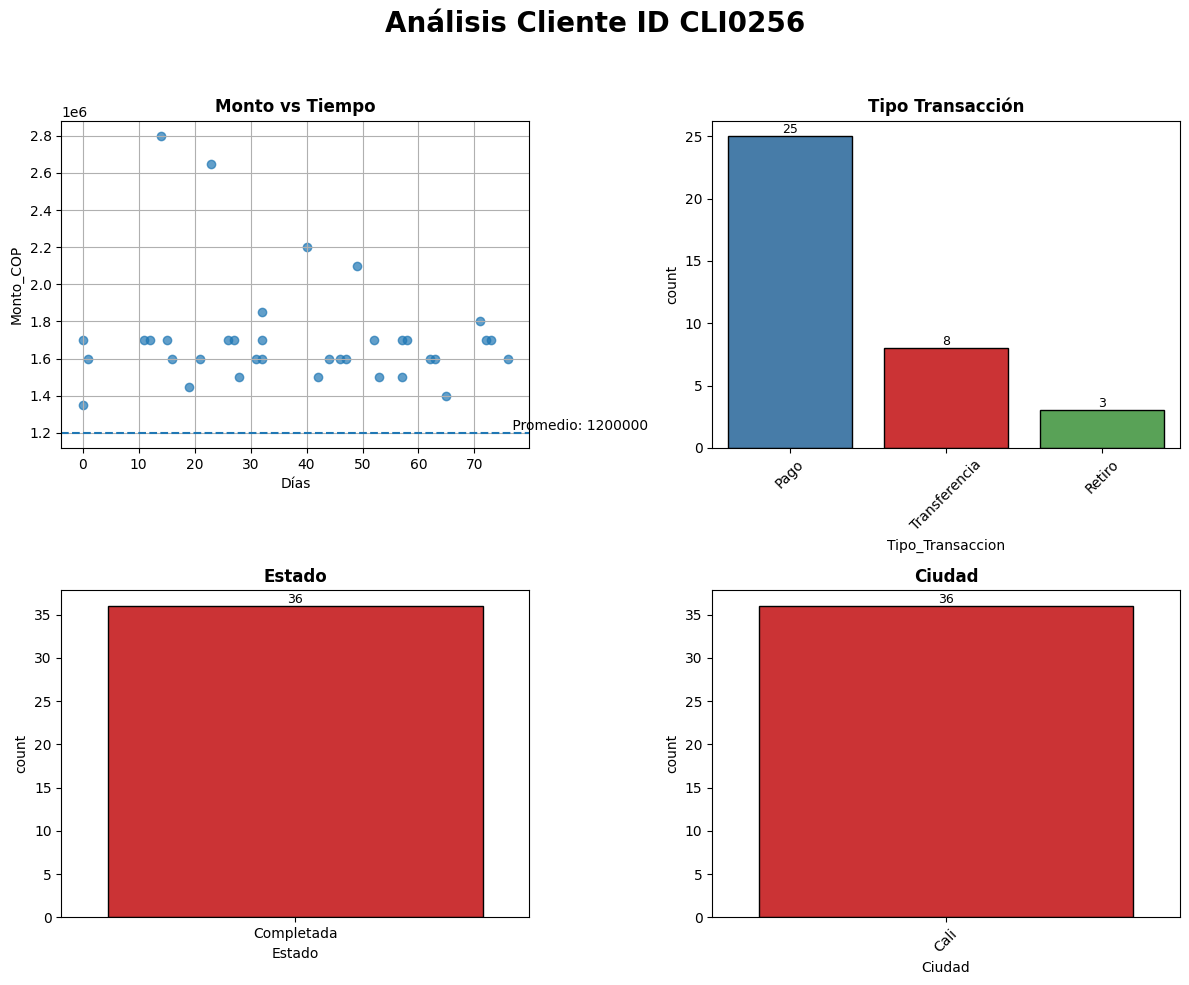

In [261]:
graficos_cliente(df,'CLI0256')

In [ ]:
df[df['Cliente_ID']=="CLI0256"].sort_values('Fecha')

## **7.4 CLI0512**

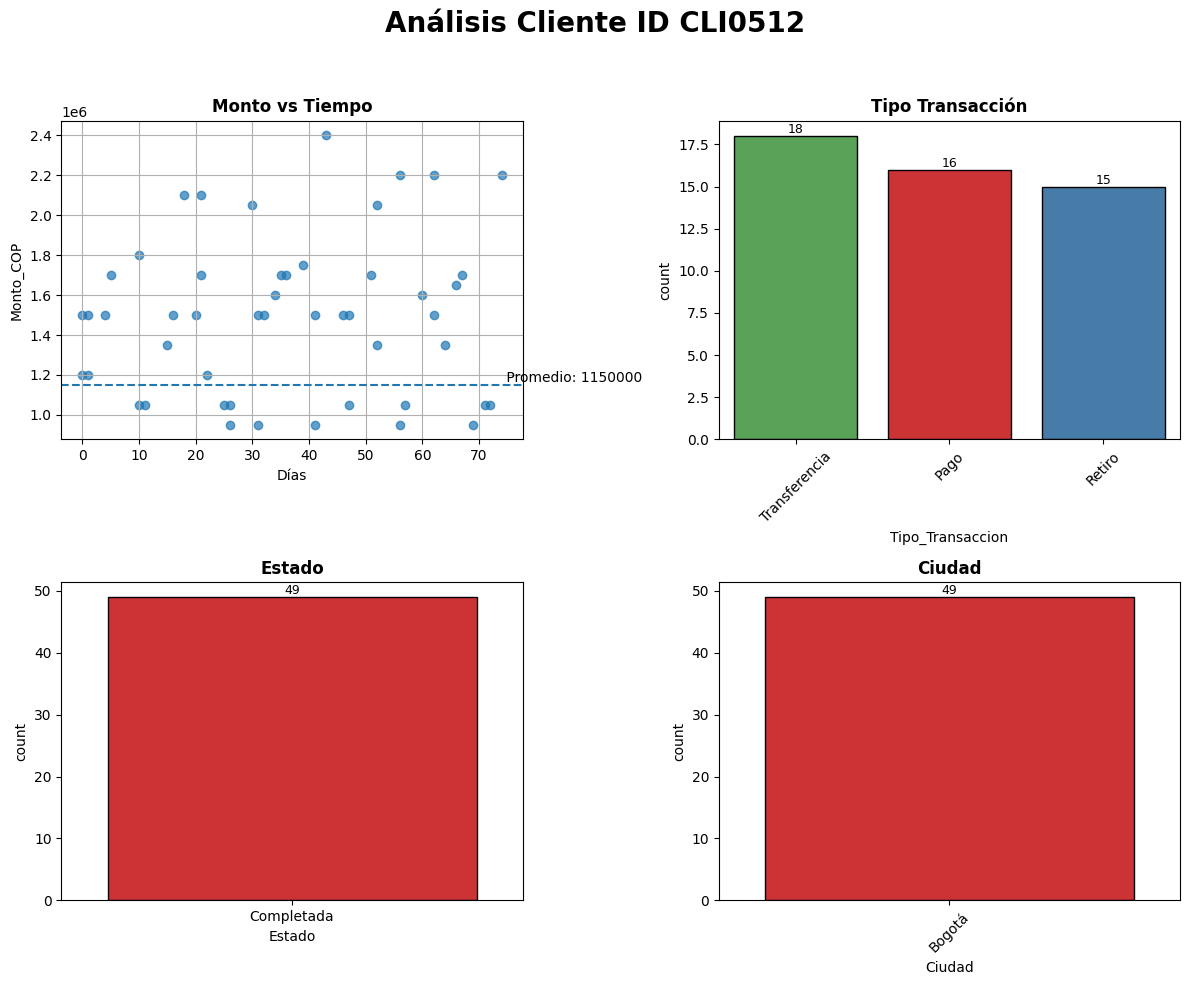

In [262]:
graficos_cliente(df,'CLI0512')

In [ ]:
df[df['Cliente_ID']=="CLI0521"].sort_values('Fecha')

## **7.5 CLI0315**

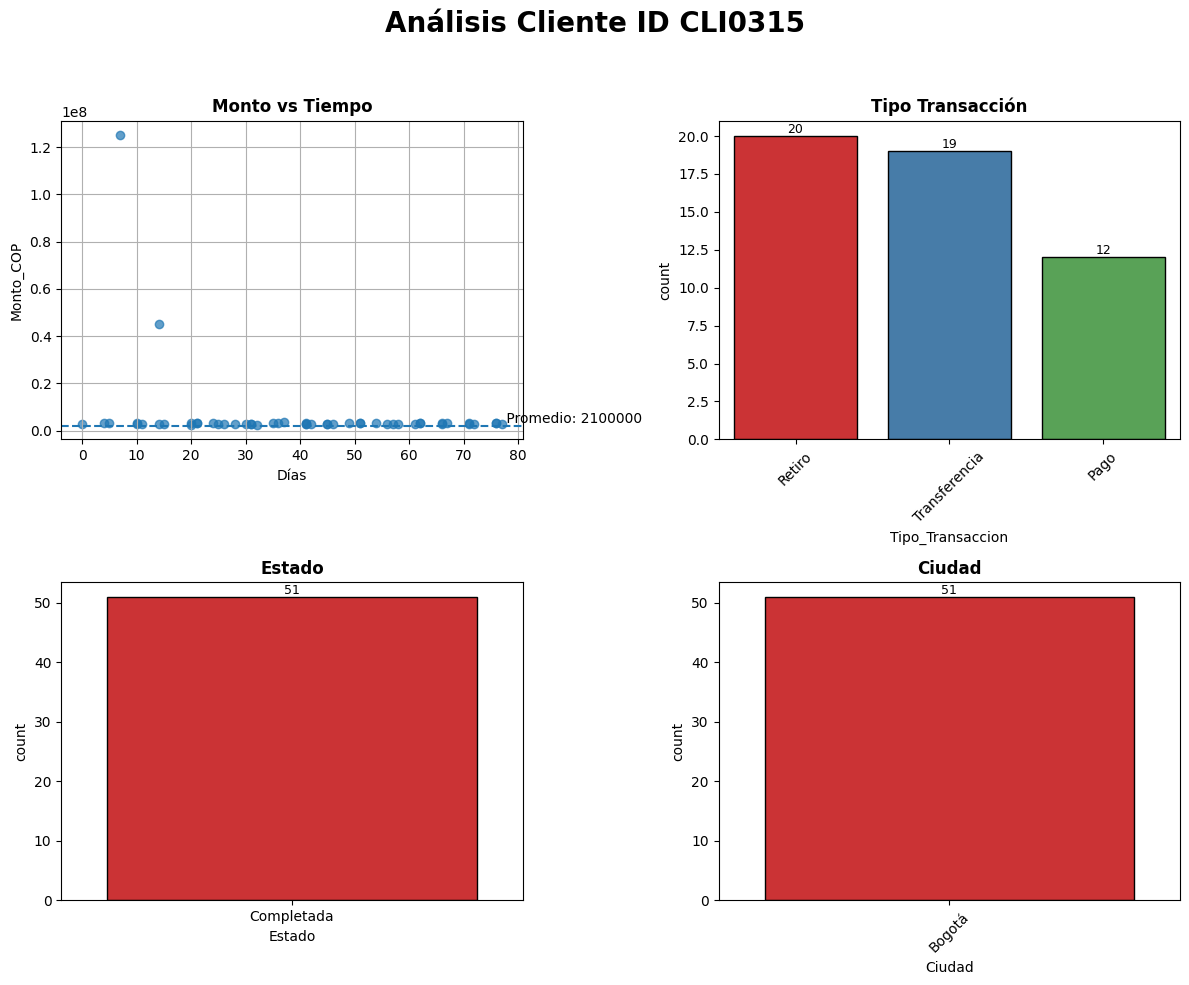

In [263]:
graficos_cliente(df,'CLI0315')

In [ ]:
df[df['Cliente_ID']=="CLI0315"].sort_values('Fecha')

## **7.6 CLI0789**

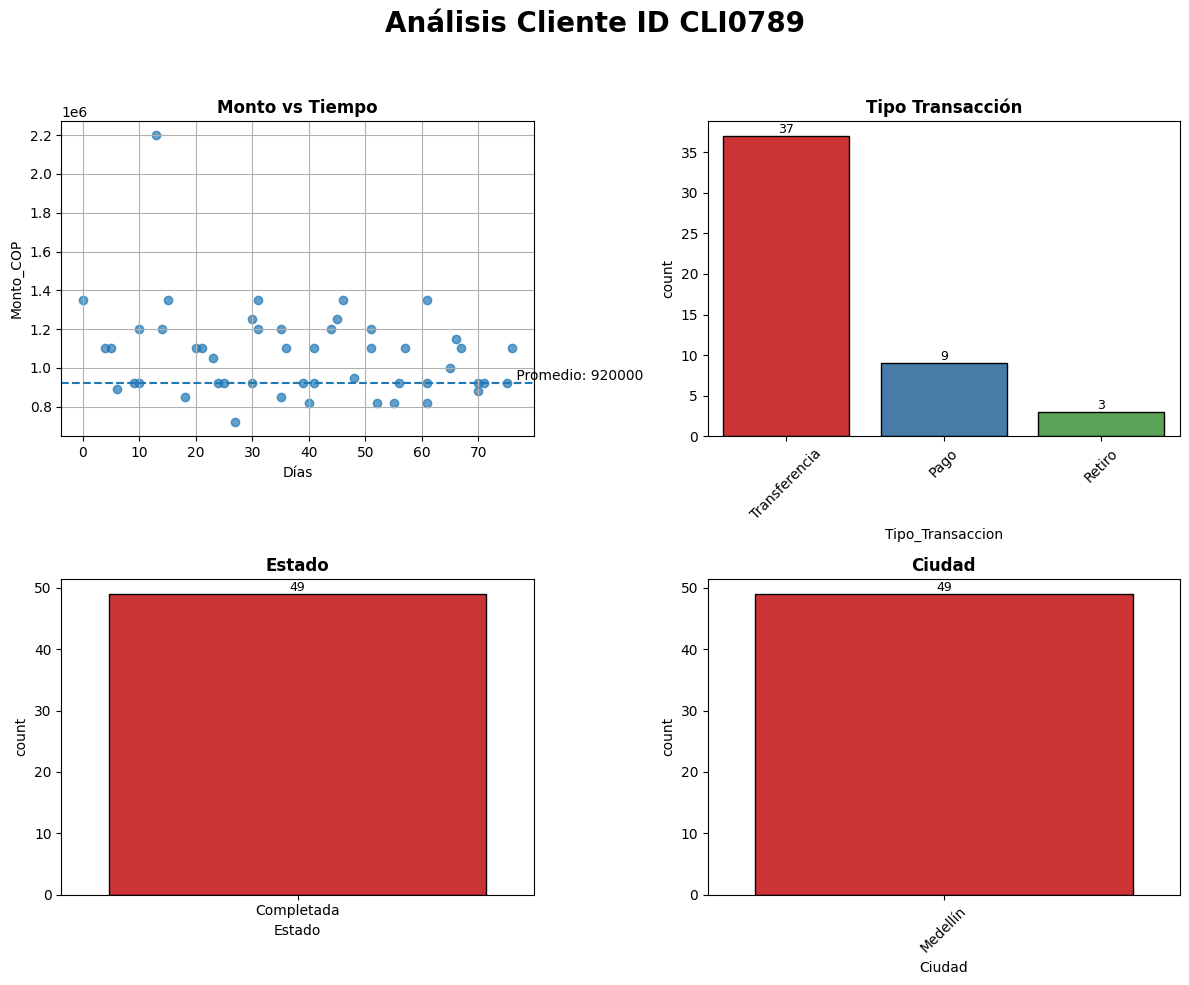

In [264]:
graficos_cliente(df,'CLI0789')

In [ ]:
df[df['Cliente_ID']=="CLI0789"].sort_values('Fecha')

## **7.7 CLI0654**

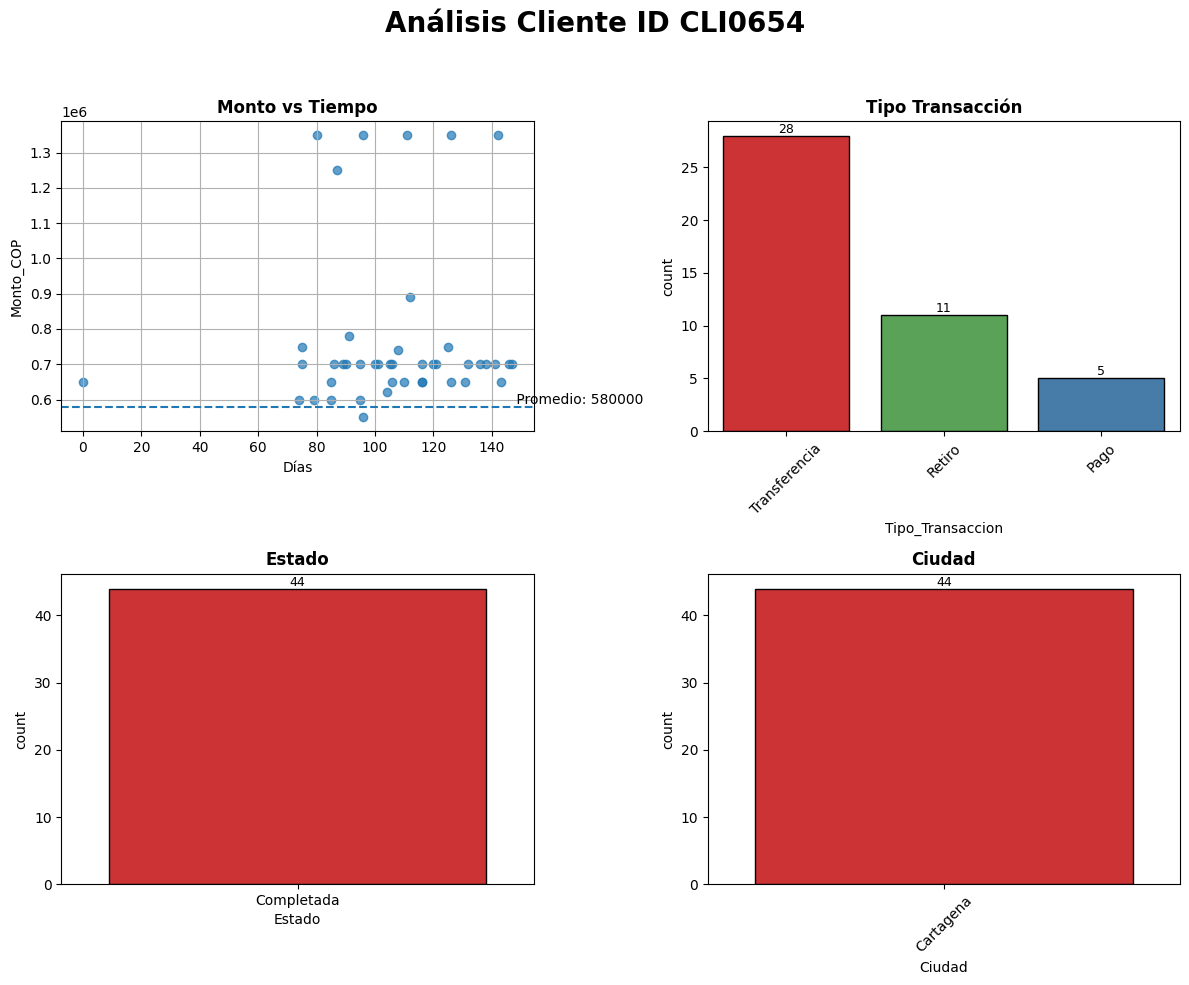

In [265]:
graficos_cliente(df,'CLI0654')

In [ ]:
df[df['Cliente_ID']=="CLI0654"].sort_values('Fecha')

# **8. Análisis, Eliminación ó Imputación de Valores Faltantes**